# Notebook 01: Feature & Label Design for Next-Day Stock Return Prediction

This notebook covers **Chapter 1 (Introduction & Problem Context)** and **Chapter 2 (Dataset & Preprocessing)** for the project **Stock Prediction Using Linear Regression**.

The notebook is intentionally structured as:
1. Detailed explanation and justification in markdown.
2. Minimal, reproducible code cells.

## Project framing
- **Domain**: Financial time-series prediction (daily stock data).
- **Objective**: Predict the next trading day's price movement magnitude as a percentage.
- **ML problem type**: Supervised **regression**.
- **Primary model in later chapters**: Linear Regression.

## Why predict next-day percentage change instead of raw price?
We use next-day percentage change as the label because it is:
- Scale-normalized across different price levels.
- Easier to compare over time.
- Directly convertible back to predicted next-day price.

Label definition:
\[
 y_t = 100 	imes 

rac{P_{t+1} - P_t}{P_t}
\]
where \(P_t\) is today's adjusted close and \(P_{t+1}\) is next trading day's adjusted close.

Predicted price can be reconstructed later with:
\[
 \hat{P}_{t+1} = P_t 	imes \left(1 + 

rac{\hat{y}_t}{100}
ight)
\]


## Exponential Smoothing (Noise Reduction) Before Feature Calculation

Following the provided research workflow, historical series are exponentially smoothed before technical indicator extraction.

Smoothing equations:
\[
S_0 = Y_0
\]
\[
S_t = lpha Y_t + (1-lpha) S_{t-1}, \quad 0 < lpha < 1
\]

Interpretation:
- Larger \(lpha\): less smoothing, more reactive to recent values.
- Smaller \(lpha\): stronger smoothing, lower short-term noise.

Implementation choice in this notebook:
- \(lpha = 0.2\), a balanced denoising setting.
- Smoothing is applied to all base inputs used by indicators: **Adj Close, High, Low, Volume**.
- Indicators are computed from these smoothed series so all final features are noise-reduced by construction.


## Chosen Feature Set 

To avoid redundant features, we keep exactly **8** indicators with distinct analytical roles.

| Feature | Category | Typical Window | What It Captures | Why Kept |
|---|---|---:|---|---|
| `rsi_14` | Momentum oscillator | 14 | Overbought/oversold pressure | Bounded momentum signal |
| `macd_hist_12_26_9` | Trend + momentum | 12, 26, 9 | Momentum shift around MACD-signal crossover | Compact trend-shift summary |
| `adx_14` | Trend strength | 14 | Strength of trend regardless of direction | Trend-vs-range regime signal |
| `atr_14` | Volatility (true range) | 14 | Gap-aware movement magnitude | Risk/volatility state |
| `obv` | Volume flow | cumulative | Buy/sell pressure via price-volume direction | Volume confirmation feature |
| `roc_10` | Momentum (% change) | 10 | Price Rate of Change (PROC/ROC) | Medium-short horizon momentum |


## Data and Label Construction Rules

- Data source: Yahoo Finance (`yfinance`) daily OHLCV.
- Main close series for target and close-based indicators: **Adjusted Close**.
- No leakage policy:
  - Features at date \(t\) use only information up to \(t\).
  - Label at date \(t\) uses \(t+1\) adjusted close.
- Rows with warm-up NaNs from rolling indicators are removed.
- Final output is saved for Notebook 02 exploration.


In [1]:
import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf
from pathlib import Path

pd.set_option("display.max_columns", 200)

In [2]:
TICKER = "AAPL"
PERIOD = "5y"
INTERVAL = "1d"
ALPHA = 0.2

OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_PATH_PARQUET = OUT_DIR / "aapl_features_smoothed.parquet"
FEATURE_PATH_CSV = OUT_DIR / "aapl_features_smoothed.csv"

In [8]:
raw = yf.download(
    TICKER,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=False,
    actions=False,
    progress=False,
)

if raw.empty:
    raise ValueError("No data returned from yfinance. Check ticker or network availability.")

# Flatten MultiIndex columns if present
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

df = raw.rename(columns={"Adj Close": "Adj_Close"}).copy()
df = df[["Open", "High", "Low", "Close", "Adj_Close", "Volume"]].dropna().copy()
df.head()

Price,Open,High,Low,Close,Adj_Close,Volume
Date,,,,,,
2021-04-12,132.520004,132.850006,130.630005,131.240005,127.827187,91420000
2021-04-13,132.440002,134.660004,131.929993,134.429993,130.934189,91266500
2021-04-14,134.940002,135.000000,131.660004,132.029999,128.596619,87222800
2021-04-15,133.820007,135.000000,133.639999,134.500000,131.002396,89347100
2021-04-16,134.300003,134.669998,133.279999,134.160004,130.671280,84922400


In [ ]:
def exp_smooth(series: pd.Series, alpha: float = 0.2) -> pd.Series:
    return series.ewm(alpha=alpha, adjust=False).mean()

s_adj_close = exp_smooth(df["Adj_Close"], ALPHA)
s_high = exp_smooth(df["High"], ALPHA)
s_low = exp_smooth(df["Low"], ALPHA)
s_volume = exp_smooth(df["Volume"], ALPHA)

feat = pd.DataFrame(index=df.index)
feat["adj_close"] = df["Adj_Close"]
feat["adj_close_smooth"] = s_adj_close

# 1) RSI(14)
feat["rsi_14"] = ta.rsi(s_adj_close, length=14)

# 2) MACD histogram (12,26,9)
macd_df = ta.macd(s_adj_close, fast=12, slow=26, signal=9)
feat["macd_hist_12_26_9"] = macd_df["MACDh_12_26_9"]

# 3-4) Bollinger percent-b and bandwidth (20,2)
bb_df = ta.bbands(s_adj_close, length=20, std=2)
bb_pctb_col = next(c for c in bb_df.columns if c.startswith("BBP_"))
bb_bw_col = next(c for c in bb_df.columns if c.startswith("BBB_"))
feat["bb_pctb_20_2"] = bb_df[bb_pctb_col]
feat["bb_bandwidth_20_2"] = bb_df[bb_bw_col]

# 5) ADX(14)
adx_df = ta.adx(high=s_high, low=s_low, close=s_adj_close, length=14)
feat["adx_14"] = adx_df["ADX_14"]

# 6) ATR(14)
feat["atr_14"] = ta.atr(high=s_high, low=s_low, close=s_adj_close, length=14)

# 7) OBV
feat["obv"] = ta.obv(close=s_adj_close, volume=s_volume)

# 8) ROC(10) = Price Rate of Change
feat["roc_10"] = ta.roc(s_adj_close, length=10)

# Label: next-day return (%)
feat["target_ret_1d_pct"] = (df["Adj_Close"].pct_change().shift(-1) * 100)

# Keep only selected 8 features + helpful price columns + target
feature_cols = [
    "rsi_14",
    "macd_hist_12_26_9",
    "bb_pctb_20_2",
    "bb_bandwidth_20_2",
    "adx_14",
    "atr_14",
    "obv",
    "roc_10",
]
keep_cols = ["adj_close", "adj_close_smooth"] + feature_cols + ["target_ret_1d_pct"]
feat = feat[keep_cols]

rows_before = len(feat)
feat = feat.dropna().copy()
rows_after = len(feat)

summary = pd.DataFrame(
    {
        "metric": ["rows_before_dropna", "rows_after_dropna", "rows_removed"],
        "value": [rows_before, rows_after, rows_before - rows_after],
    }
)
summary

,metric,value
0,rows_before_dropna,1256
1,rows_after_dropna,1222
2,rows_removed,34


## Smoothed vs Actual Adjusted Close

This visualization confirms the effect of exponential smoothing before indicator extraction.

Interpretation guide:
- The smoothed series should follow the same broad trend as the original adjusted close.
- Short-term noise should be reduced in the smoothed curve.
- This supports clearer technical indicator signals for later modeling and EDA.


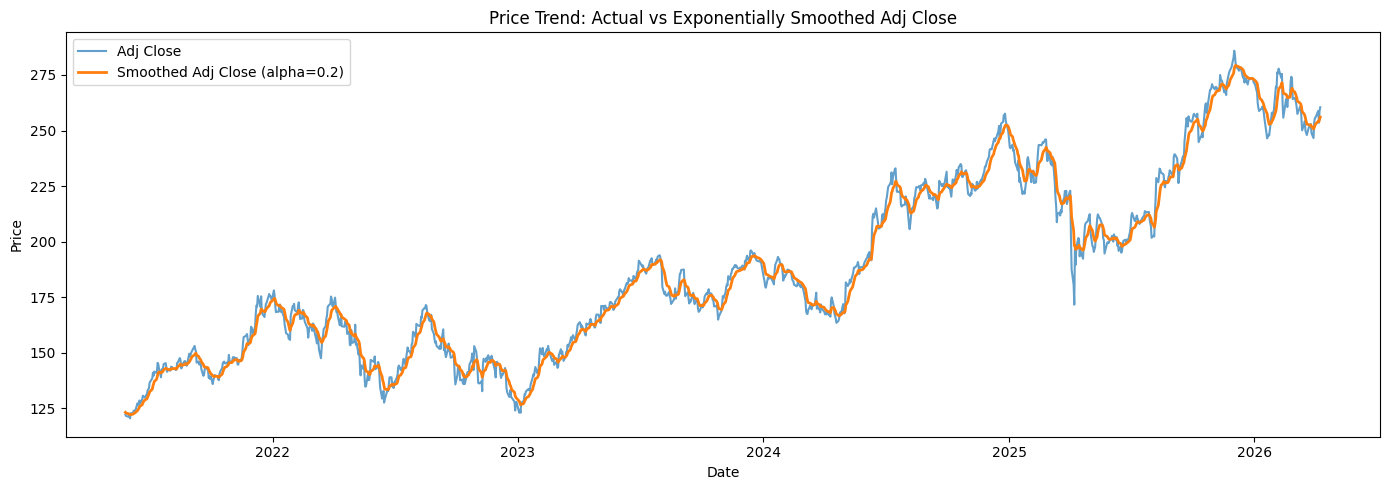

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(feat.index, feat["adj_close"], label="Adj Close", alpha=0.7)
ax.plot(feat.index, feat["adj_close_smooth"], label=f"Smoothed Adj Close (alpha={ALPHA})", linewidth=2)
ax.set_title("Price Trend: Actual vs Exponentially Smoothed Adj Close")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# Save feature dataset for Notebook 02
saved_to = None
try:
    feat.to_parquet(FEATURE_PATH_PARQUET)
    saved_to = str(FEATURE_PATH_PARQUET)
except Exception:
    feat.to_csv(FEATURE_PATH_CSV, index=True)
    saved_to = str(FEATURE_PATH_CSV)

print("Saved processed feature dataset to:", saved_to)
feat.head()

Saved processed feature dataset to: ..\data\processed\aapl_features_smoothed.csv


,adj_close,adj_close_smooth,rsi_14,macd_hist_12_26_9,bb_bandwidth_20_2,adx_14,atr_14,obv,roc_10,target_ret_1d_pct
Date,,,,,,,,,,
2021-05-27,122.229416,123.247685,31.926834,0.170177,7.415559,55.268885,4.395619,-5.688121e+08,-0.723586,-0.534784
2021-05-28,121.575752,122.913298,29.701025,0.171716,6.849811,54.934163,4.372074,-6.457471e+08,-1.024920,-0.264848
2021-06-01,121.253761,122.581391,27.641150,0.160694,6.134840,54.865161,4.346043,-7.208225e+08,-1.134432,0.627642
2021-06-02,122.014801,122.468073,26.953833,0.155960,5.571166,54.967599,4.321565,-7.927386e+08,-0.877575,-1.215428
2021-06-03,120.531799,122.080818,24.694009,0.137577,5.152103,55.326148,4.282148,-8.655174e+08,-0.886408,1.902218


## Notebook 01 Deliverables Checklist

- [x] Label definition and justification documented.
- [x] Exponential smoothing formula and preprocessing logic documented.
- [x] Exactly 8 selected features engineered and justified.
- [x] Overlap removals documented.
- [x] Final feature DataFrame exported for EDA (Notebook 02).
